# Import Dependencies
**Muhammad Raihan Hassan - 5026231108**

In [5]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to C:\Users\ASUS
[nltk_data]     Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Define Document

In [6]:
sentence2 = """Surabaya: Pemerintah Kota Surabaya terus berinovasi dalam mengintegrasikan layanan transportasi publik untuk kenyamanan warga. Melalui aplikasi Gobis Suroboyo, pengguna dapat melacak posisi armada bus secara real-time.

Aplikasi ini menjadi tulang punggung digitalisasi transportasi massal di wilayah Surabaya. Dengan adanya fitur pemantauan rute yang presisi, masyarakat tidak perlu lagi menunggu lama di halte tanpa kepastian kedatangan bus.

Inisiatif ini tidak hanya meningkatkan efisiensi waktu perjalanan, tetapi juga mendorong lebih banyak warga untuk beralih dari kendaraan pribadi ke kendaraan umum. Hal ini sangat penting untuk mengurangi emisi karbon di kota-kota besar.

Ke depan, Dinas Perhubungan Surabaya berencana menambahkan fitur pembayaran terintegrasi di dalam aplikasi Gobis Suroboyo. Langkah ini diyakini akan mewujudkan ekosistem transportasi cerdas yang semakin mulus dan terjangkau bagi semua lapisan masyarakat.

"Kami terus mengevaluasi performa aplikasi Gobis agar selalu bisa memenuhi kebutuhan mobilitas warga Surabaya yang sangat dinamis," ungkap perwakilan Dishub Surabaya dalam konferensi pers minggu lalu.

Pengembangan transportasi berbasis aplikasi ini merupakan salah satu pilar utama dalam mewujudkan konsep Smart City di Surabaya. Diharapkan, kota-kota lain di Indonesia dapat mereplikasi kesuksesan integrasi sistem transportasi cerdas ini.
"""

# Text Preprocessing

In [7]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\ASUS
[nltk_data]     Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print(sent_token2)

['Surabaya: Pemerintah Kota Surabaya terus berinovasi dalam mengintegrasikan layanan transportasi publik untuk kenyamanan warga.', 'Melalui aplikasi Gobis Suroboyo, pengguna dapat melacak posisi armada bus secara real-time.', 'Aplikasi ini menjadi tulang punggung digitalisasi transportasi massal di wilayah Surabaya.', 'Dengan adanya fitur pemantauan rute yang presisi, masyarakat tidak perlu lagi menunggu lama di halte tanpa kepastian kedatangan bus.', 'Inisiatif ini tidak hanya meningkatkan efisiensi waktu perjalanan, tetapi juga mendorong lebih banyak warga untuk beralih dari kendaraan pribadi ke kendaraan umum.', 'Hal ini sangat penting untuk mengurangi emisi karbon di kota-kota besar.', 'Ke depan, Dinas Perhubungan Surabaya berencana menambahkan fitur pembayaran terintegrasi di dalam aplikasi Gobis Suroboyo.', 'Langkah ini diyakini akan mewujudkan ekosistem transportasi cerdas yang semakin mulus dan terjangkau bagi semua lapisan masyarakat.', '"Kami terus mengevaluasi performa aplik

Kode di atas digunakan untuk memecah teks panjang menjadi beberapa kalimat.

Fungsi sent_tokenize() dari NLTK akan membaca teks dan memisahkannya berdasarkan tanda baca seperti titik (.), tanda tanya (?), dan tanda seru (!).

Hasilnya adalah sebuah list yang berisi kalimat-kalimat terpisah, sehingga teks menjadi lebih mudah untuk diproses dan dianalisis pada tahap selanjutnya.

In [9]:
!pip install Sastrawi

Pada kode ini, teks berita terlebih dahulu dipecah menjadi beberapa kalimat menggunakan sent_tokenize(). Setelah itu, setiap kalimat dibersihkan dengan menghapus kata-kata umum (stopwords) Bahasa Indonesia menggunakan library Sastrawi.

Selanjutnya, kalimat yang sudah dibersihkan diubah menjadi bentuk numerik menggunakan metode TF-IDF (Term Frequency-Inverse Document Frequency). Proses ini dilakukan dengan TfidfVectorizer().

TF-IDF memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya. Kata yang sering muncul dalam satu kalimat tetapi jarang muncul di kalimat lain akan memiliki nilai yang lebih tinggi.

Hasil akhirnya berupa matriks TF-IDF yang menunjukkan representasi numerik dari setiap kalimat, sehingga dapat digunakan untuk analisis lanjutan seperti klasifikasi atau pencarian informasi.

In [10]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for sent in sent_token2:
    print(sent)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# Feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# TF-IDF untuk kalimat pertama
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

Tokenized sentences:
Surabaya: Pemerintah Kota Surabaya terus berinovasi dalam mengintegrasikan layanan transportasi publik untuk kenyamanan warga.
Melalui aplikasi Gobis Suroboyo, pengguna dapat melacak posisi armada bus secara real-time.
Aplikasi ini menjadi tulang punggung digitalisasi transportasi massal di wilayah Surabaya.
Dengan adanya fitur pemantauan rute yang presisi, masyarakat tidak perlu lagi menunggu lama di halte tanpa kepastian kedatangan bus.
Inisiatif ini tidak hanya meningkatkan efisiensi waktu perjalanan, tetapi juga mendorong lebih banyak warga untuk beralih dari kendaraan pribadi ke kendaraan umum.
Hal ini sangat penting untuk mengurangi emisi karbon di kota-kota besar.
Ke depan, Dinas Perhubungan Surabaya berencana menambahkan fitur pembayaran terintegrasi di dalam aplikasi Gobis Suroboyo.
Langkah ini diyakini akan mewujudkan ekosistem transportasi cerdas yang semakin mulus dan terjangkau bagi semua lapisan masyarakat.
"Kami terus mengevaluasi performa aplikasi G

Pada bagian ini, nilai TF-IDF yang telah dihitung sebelumnya divisualisasikan menggunakan grafik batang (bar chart).

Data yang digunakan adalah nilai TF-IDF dari kata-kata pada kalimat pertama setelah proses pembersihan (stopwords removal). Setiap kata ditampilkan pada sumbu X, sedangkan nilai TF-IDF ditampilkan pada sumbu Y.

Visualisasi ini membantu kita melihat kata mana yang paling penting dalam suatu kalimat. Semakin tinggi nilai TF-IDF, semakin besar pengaruh kata tersebut dalam kalimat.

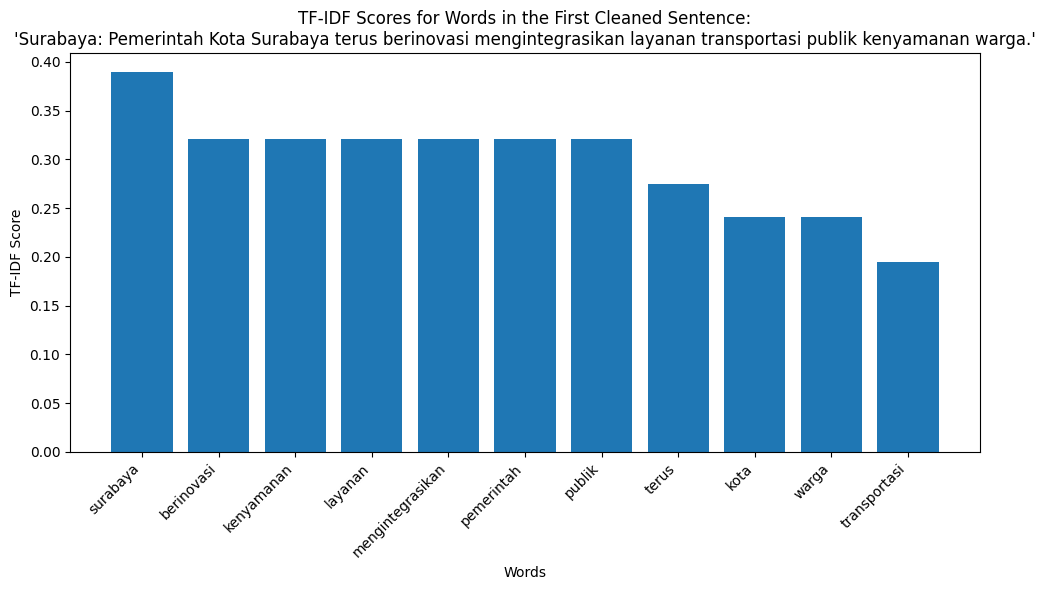

In [11]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualisasi
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

In [12]:
# Summarization process
sentence_scores = np.asarray(features.sum(axis=1)).ravel()
top_n = 3
top_sentence_indices = sentence_scores.argsort()[-top_n:][::-1]
top_sentence_indices.sort()

final_summ = " ".join([sent_token2[i] for i in top_sentence_indices])

# Summarization Result

In [13]:
final_summ

'Dengan adanya fitur pemantauan rute yang presisi, masyarakat tidak perlu lagi menunggu lama di halte tanpa kepastian kedatangan bus. Inisiatif ini tidak hanya meningkatkan efisiensi waktu perjalanan, tetapi juga mendorong lebih banyak warga untuk beralih dari kendaraan pribadi ke kendaraan umum. "Kami terus mengevaluasi performa aplikasi Gobis agar selalu bisa memenuhi kebutuhan mobilitas warga Surabaya yang sangat dinamis," ungkap perwakilan Dishub Surabaya dalam konferensi pers minggu lalu.'